In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


df = pd.read_csv("master_dataset_model_ready_v4.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Dataset shape: (21329, 33)
       date       station  District District_no  index_right  daily_max_aqhi  daily_mean_aqhi  hourly_count  starred_hours  lag1_aqhi  lag2_aqhi  lag3_aqhi  lag7_aqhi  rolling3_mean_aqhi  \
0  2023/1/1  Causeway Bay  Wan Chai           B            1             4.0         3.541667            24              0        NaN        NaN        NaN        NaN                 NaN   
1  2023/1/2  Causeway Bay  Wan Chai           B            1             5.0         3.625000            24              0        4.0        NaN        NaN        NaN                 NaN   
2  2023/1/3  Causeway Bay  Wan Chai           B            1             5.0         3.416667            24              0        5.0        4.0        NaN        NaN                 NaN   
3  2023/1/4  Causeway Bay  Wan Chai           B            1             5.0         3.791667            24              0        5.0        5.0        4.0        NaN            4.666667   
4  2023/1/5  Causeway B

In [ ]:

# 2. Basic cleaning

df.columns = df.columns.str.strip()

# Convert date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Strip text columns
for col in ["station", "District"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print("\nData types:")
print(df.dtypes)

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

print("\nMissing values (%):")
print((df.isna().mean() * 100).sort_values(ascending=False))


Data types:
date                    datetime64[ns]
station                         object
District                        object
District_no                     object
index_right                      int64
daily_max_aqhi                 float64
daily_mean_aqhi                float64
hourly_count                     int64
starred_hours                    int64
lag1_aqhi                      float64
lag2_aqhi                      float64
lag3_aqhi                      float64
lag7_aqhi                      float64
rolling3_mean_aqhi             float64
rolling7_mean_aqhi             float64
rolling14_mean_aqhi            float64
target_next_day                  int64
high_risk_next_day               int64
year                             int64
month                            int64
day                              int64
day_of_week                      int64
is_weekend                       int64
rain_mm                        float64
rain_trace_flag                  int64
rain_occurre

In [ ]:

# 3. Check target columns

print("\nUnique values in target_next_day:")
print(df["target_next_day"].value_counts(dropna=False))

print("\nUnique values in high_risk_next_day:")
print(df["high_risk_next_day"].value_counts(dropna=False))

# Check whether they are identical
same_target = (df["target_next_day"] == df["high_risk_next_day"]).all()
print("\nAre target_next_day and high_risk_next_day identical?", same_target)

# If identical, keep only one target column
if same_target:
    df = df.drop(columns=["target_next_day"])
    target_col = "high_risk_next_day"
else:
    # Choose one manually if not identical
    target_col = "high_risk_next_day"

print("\nChosen target column:", target_col)


Unique values in target_next_day:
target_next_day
4     5535
3     5433
5     4469
6     2522
2     1922
7      868
8      342
9      128
10     106
1        4
Name: count, dtype: int64

Unique values in high_risk_next_day:
high_risk_next_day
0    19885
1     1444
Name: count, dtype: int64

Are target_next_day and high_risk_next_day identical? False

Chosen target column: high_risk_next_day


In [ ]:

# 4. Basic EDA summary

print("\nDataset info:")
print(df.info())

print("\nDescriptive statistics:")
print(df.describe(include="all"))

print("\nDuplicated rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df[target_col].value_counts(dropna=False))
print(df[target_col].value_counts(normalize=True, dropna=False))


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21329 entries, 0 to 21328
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  21329 non-null  datetime64[ns]
 1   station               21329 non-null  object        
 2   District              21329 non-null  object        
 3   District_no           21329 non-null  object        
 4   index_right           21329 non-null  int64         
 5   daily_max_aqhi        21328 non-null  float64       
 6   daily_mean_aqhi       21328 non-null  float64       
 7   hourly_count          21329 non-null  int64         
 8   starred_hours         21329 non-null  int64         
 9   lag1_aqhi             21310 non-null  float64       
 10  lag2_aqhi             21292 non-null  float64       
 11  lag3_aqhi             21274 non-null  float64       
 12  lag7_aqhi             21202 non-null  float64       
 13  r

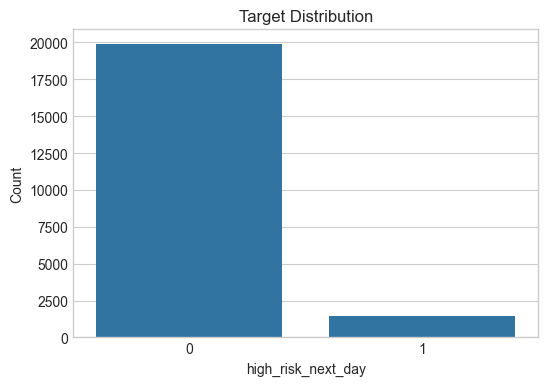

High-risk positive rate: 0.0677 (6.77%)


In [ ]:

# 5. Plot target distribution

plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Target Distribution")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.show()

target_rate = df[target_col].mean()
print(f"High-risk positive rate: {target_rate:.4f} ({target_rate*100:.2f}%)")


Station summary:
                 n_obs  positive_rate  avg_daily_max_aqhi  avg_daily_mean_aqhi
station                                                                       
Causeway Bay      1185       0.068354            4.455696             3.597995
Central           1185       0.051477            4.316456             3.486482
Central/Western   1185       0.059916            4.231224             3.427336
Eastern           1185       0.047257            4.301266             3.519925
Kwai Chung        1185       0.061603            4.209283             3.353002
Kwun Tong         1185       0.048101            4.153586             3.353659
Mong Kok          1185       0.065823            4.430380             3.571781
North             1185       0.079325            4.314768             3.322187
Sha Tin           1185       0.054008            4.154430             3.256599
Sham Shui Po      1185       0.046414            4.192405             3.373908
Southern          1185       0.063

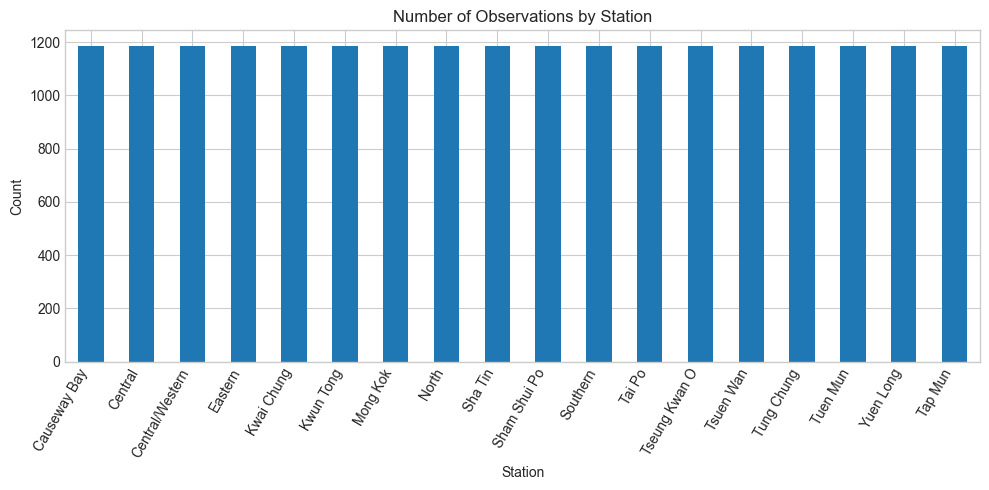

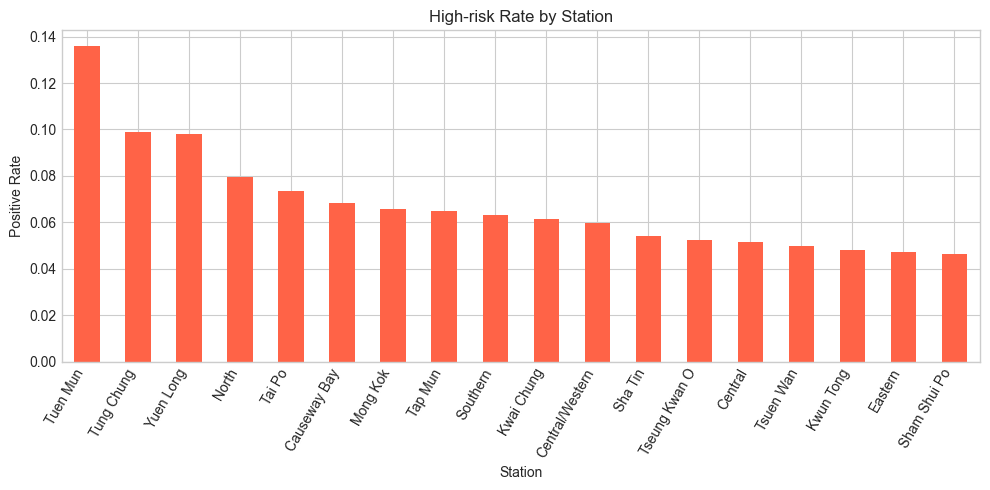

In [ ]:

# 6. Station-level summary

station_summary = (
    df.groupby("station")
      .agg(
          n_obs=(target_col, "size"),
          positive_rate=(target_col, "mean"),
          avg_daily_max_aqhi=("daily_max_aqhi", "mean"),
          avg_daily_mean_aqhi=("daily_mean_aqhi", "mean")
      )
      .sort_values("n_obs", ascending=False)
)

print("\nStation summary:")
print(station_summary)

# Plot top stations by sample size
plt.figure(figsize=(10,5))
station_summary["n_obs"].sort_values(ascending=False).plot(kind="bar")
plt.title("Number of Observations by Station")
plt.ylabel("Count")
plt.xlabel("Station")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Plot positive rate by station
plt.figure(figsize=(10,5))
station_summary["positive_rate"].sort_values(ascending=False).plot(kind="bar", color="tomato")
plt.title("High-risk Rate by Station")
plt.ylabel("Positive Rate")
plt.xlabel("Station")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


District summary:
                   n_obs  positive_rate  avg_rain_mm   avg_wind   avg_temp
District                                                                  
Central & Western   2370       0.055696     5.900000  12.522616  23.509114
Tai Po              2369       0.069228     6.182989  11.284466  23.191726
Islands             1185       0.098734     5.062131  15.070675  23.061857
Eastern             1185       0.047257     6.548945  12.014430  23.223249
Kwun Tong           1185       0.048101     0.000000  10.028228  23.354051
North               1185       0.079325     5.623207   6.779114  23.759409
Sai Kung            1185       0.052321     4.856118   9.296878  22.776498
Kwai Tsing          1185       0.061603     5.339241   8.119198  23.770211
Sha Tin             1185       0.054008     6.844726   6.739156  23.661435
Sham Shui Po        1185       0.046414     6.055274  10.028228  23.992025
Southern            1185       0.063291     0.000000  10.551266  23.878228
Tsuen 

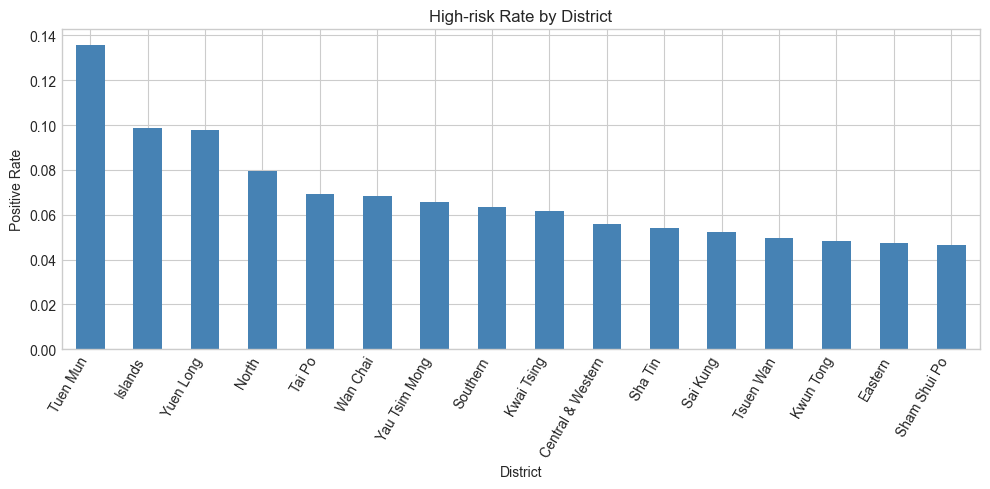

In [ ]:

# 7. District-level summary

district_summary = (
    df.groupby("District")
      .agg(
          n_obs=(target_col, "size"),
          positive_rate=(target_col, "mean"),
          avg_rain_mm=("rain_mm", "mean"),
          avg_wind=("daily_mean_wspd", "mean"),
          avg_temp=("daily_mean_temp", "mean")
      )
      .sort_values("n_obs", ascending=False)
)

print("\nDistrict summary:")
print(district_summary)

plt.figure(figsize=(10,5))
district_summary["positive_rate"].sort_values(ascending=False).plot(kind="bar", color="steelblue")
plt.title("High-risk Rate by District")
plt.ylabel("Positive Rate")
plt.xlabel("District")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


Monthly summary:
    month  n_obs  positive_rate  avg_daily_mean_aqhi  avg_rain_mm   avg_temp
0       1   2232       0.111111             3.990508     0.266476  16.466129
1       2   2034       0.046214             3.482728     0.519604  18.130629
2       3   2232       0.071685             3.646033     1.571113  20.119310
3       4   1602       0.100499             3.542633     1.343914  23.043602
4       5   1674       0.067503             3.493401     5.722252  25.750836
5       6   1620       0.004321             2.477781    10.230278  28.022469
6       7   1674       0.077061             2.522885     9.711320  28.926583
7       8   1674       0.017324             2.566201    10.866368  28.505257
8       9   1619       0.076590             2.784021    15.303968  28.032798
9      10   1674       0.048984             3.566252     3.982661  25.966547
10     11   1620       0.071605             3.759300     1.658719  21.923951
11     12   1674       0.108124             4.013997     0

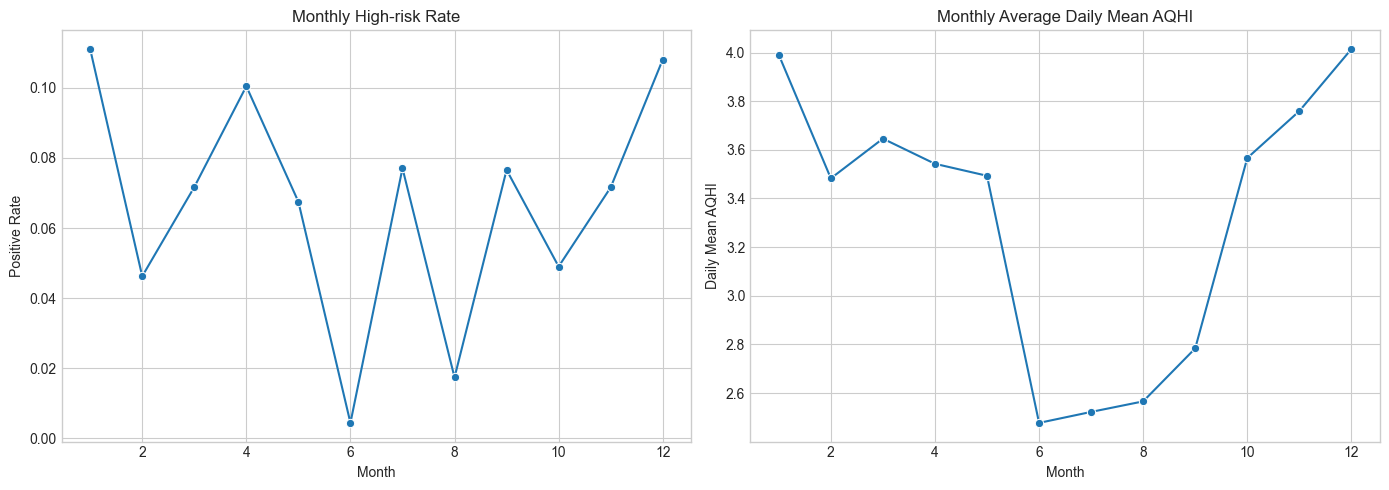

In [ ]:

# 8. Monthly pattern

monthly_summary = (
    df.groupby("month")
      .agg(
          n_obs=(target_col, "size"),
          positive_rate=(target_col, "mean"),
          avg_daily_mean_aqhi=("daily_mean_aqhi", "mean"),
          avg_rain_mm=("rain_mm", "mean"),
          avg_temp=("daily_mean_temp", "mean")
      )
      .reset_index()
)

print("\nMonthly summary:")
print(monthly_summary)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.lineplot(data=monthly_summary, x="month", y="positive_rate", marker="o", ax=axes[0])
axes[0].set_title("Monthly High-risk Rate")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Positive Rate")

sns.lineplot(data=monthly_summary, x="month", y="avg_daily_mean_aqhi", marker="o", ax=axes[1])
axes[1].set_title("Monthly Average Daily Mean AQHI")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Daily Mean AQHI")

plt.tight_layout()
plt.show()


Numeric summary:
                       count       mean        std       min        25%        50%        75%         max
daily_max_aqhi       21328.0   4.255251   1.478030  1.000000   3.000000   4.000000   5.000000   10.000000
daily_mean_aqhi      21328.0   3.350945   1.019930  1.000000   2.500000   3.250000   4.083333    8.833333
hourly_count         21329.0  23.956210   0.494868  0.000000  24.000000  24.000000  24.000000   24.000000
starred_hours        21329.0   0.608467   1.988330  0.000000   0.000000   0.000000   0.000000   24.000000
lag1_aqhi            21310.0   4.255514   1.478612  1.000000   3.000000   4.000000   5.000000   10.000000
lag2_aqhi            21292.0   4.255730   1.479218  1.000000   3.000000   4.000000   5.000000   10.000000
lag3_aqhi            21274.0   4.255335   1.479693  1.000000   3.000000   4.000000   5.000000   10.000000
lag7_aqhi            21202.0   4.256815   1.480509  1.000000   3.000000   4.000000   5.000000   10.000000
rolling3_mean_aqhi   21272.0

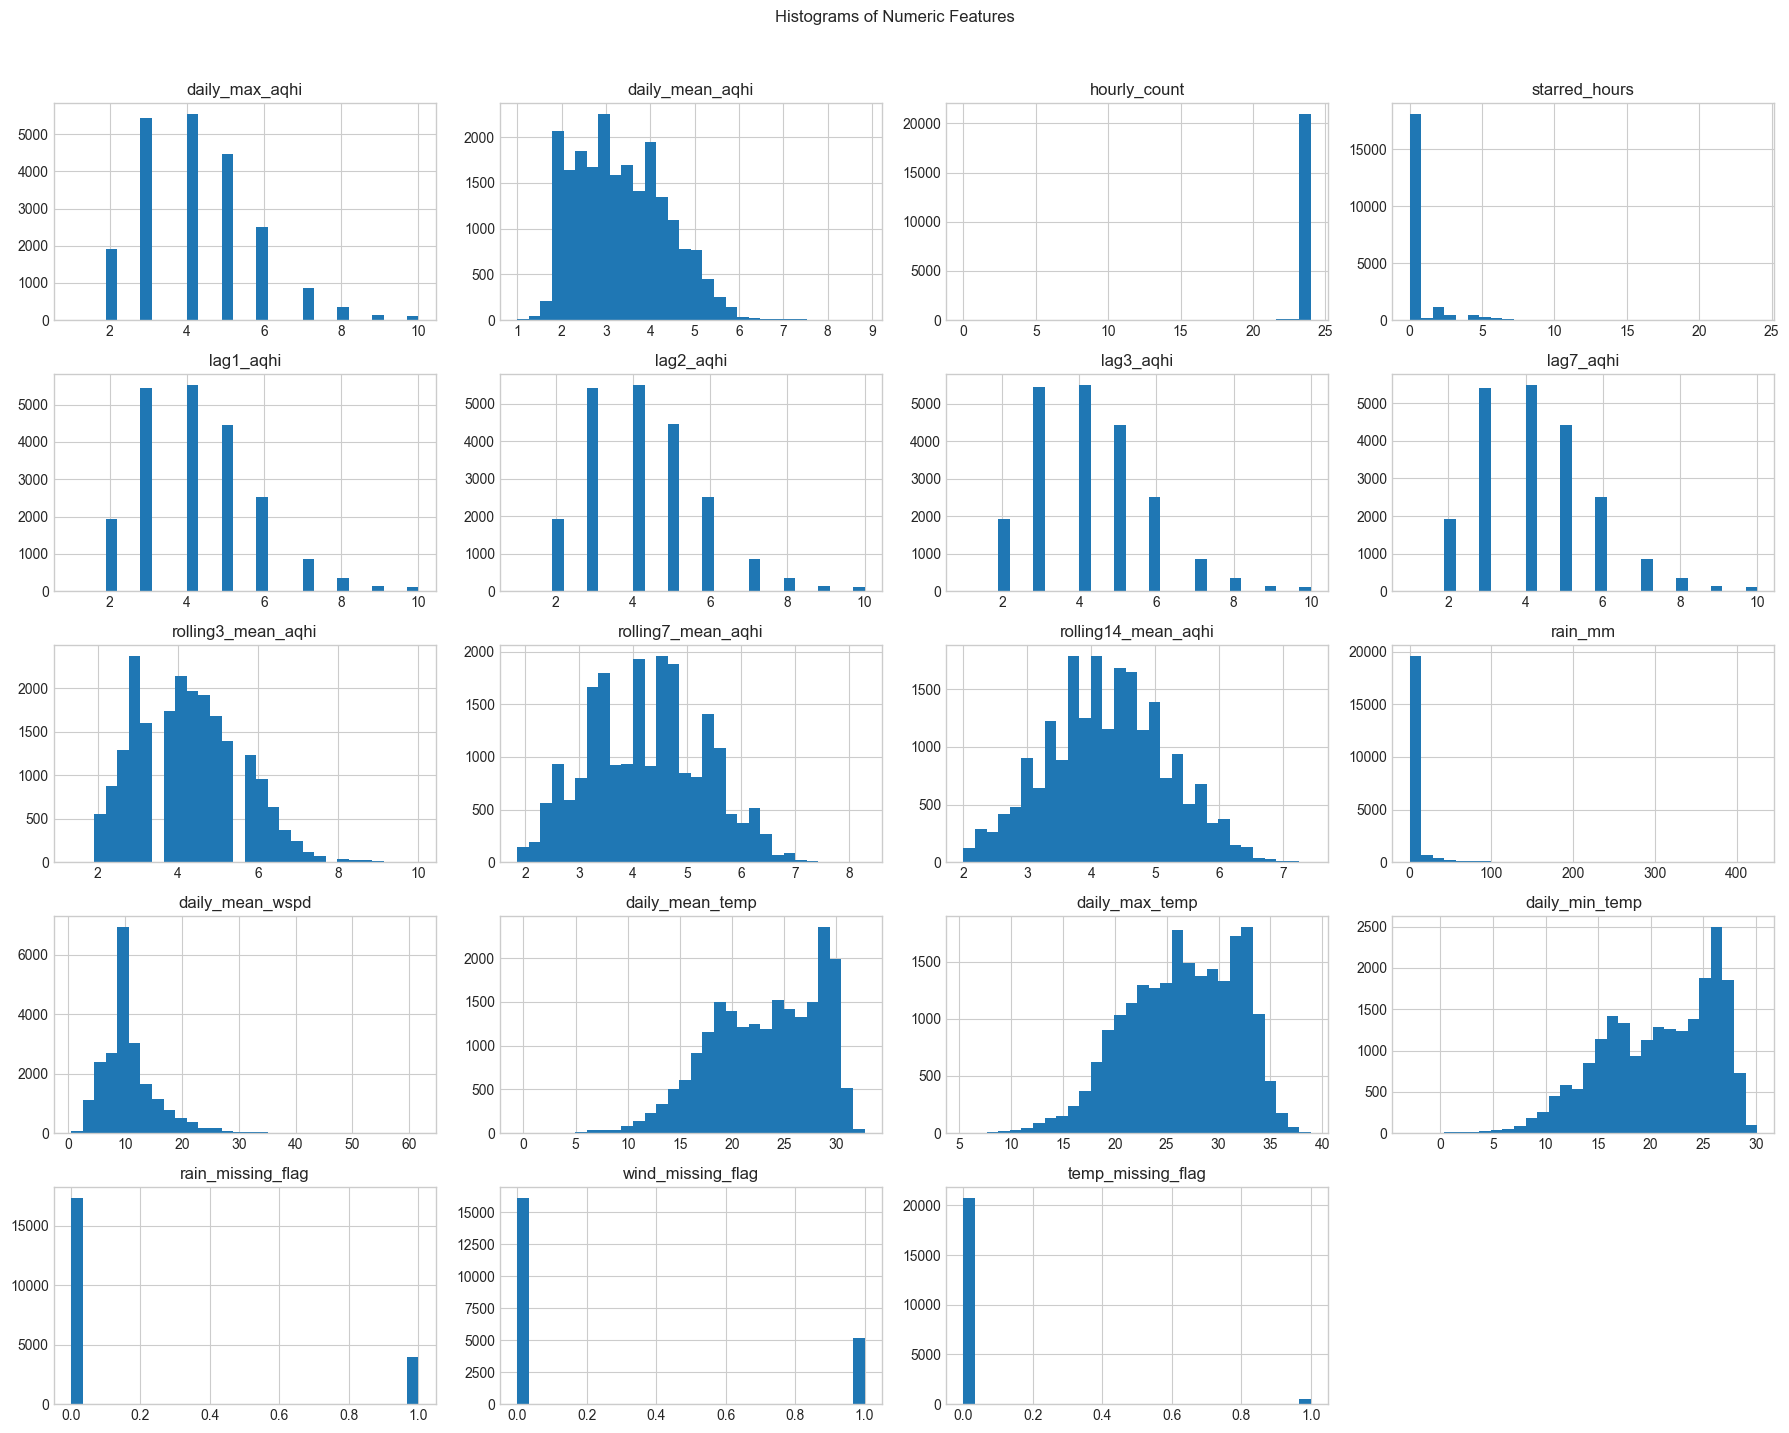

In [ ]:

# 9. Numeric feature summary

numeric_cols = [
    "daily_max_aqhi", "daily_mean_aqhi",
    "hourly_count", "starred_hours",
    "lag1_aqhi", "lag2_aqhi", "lag3_aqhi", "lag7_aqhi",
    "rolling3_mean_aqhi", "rolling7_mean_aqhi", "rolling14_mean_aqhi",
    "rain_mm", "daily_mean_wspd",
    "daily_mean_temp", "daily_max_temp", "daily_min_temp",
    "rain_missing_flag", "wind_missing_flag", "temp_missing_flag"
]

numeric_cols = [col for col in numeric_cols if col in df.columns]

print("\nNumeric summary:")
print(df[numeric_cols].describe().T)

# Histograms
df[numeric_cols].hist(figsize=(18,14), bins=30)
plt.suptitle("Histograms of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

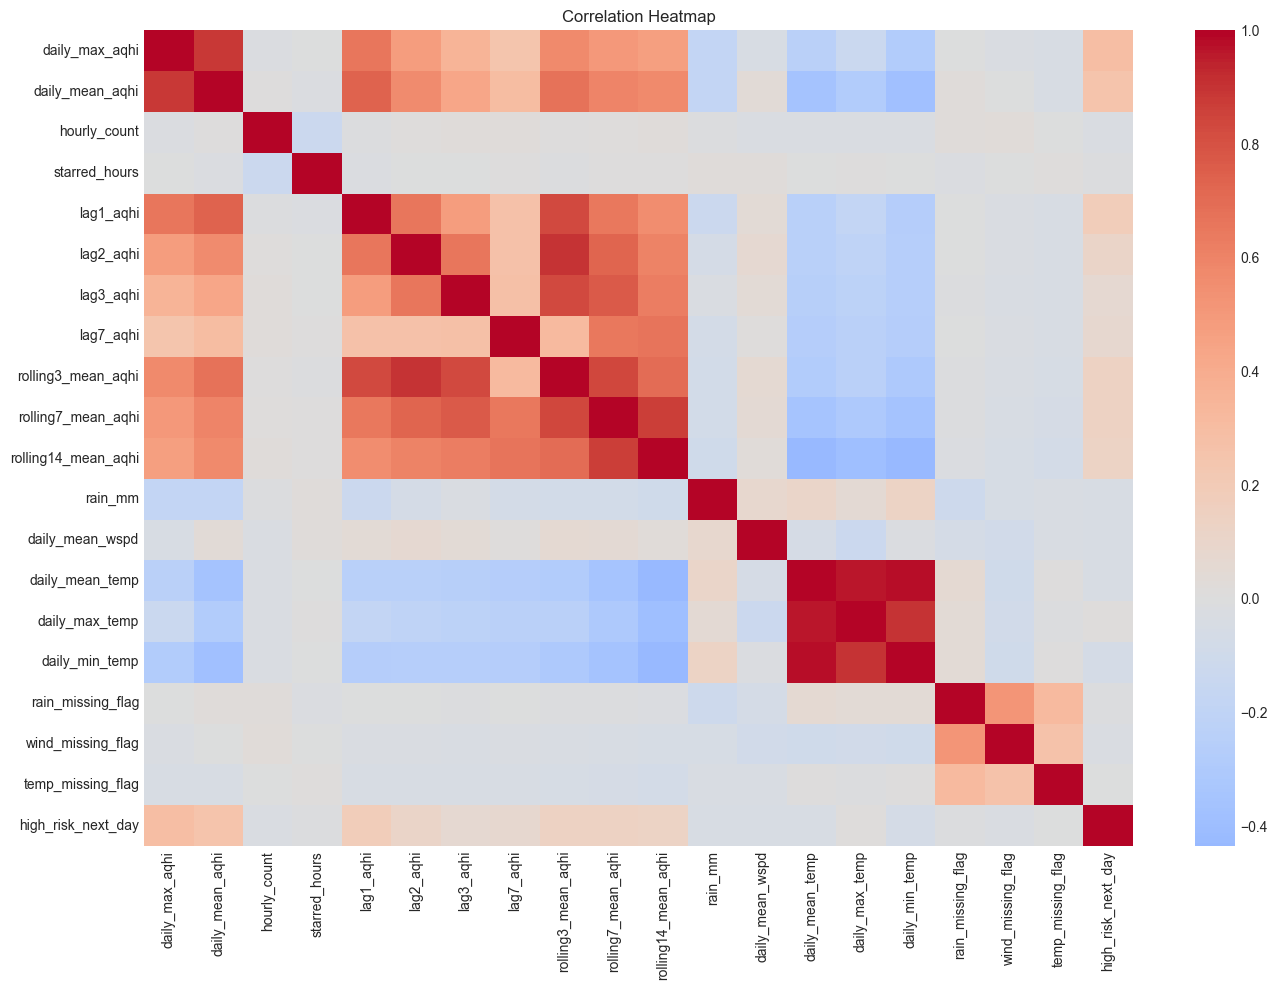

In [ ]:

# 10. Correlation heatmap

corr_cols = [col for col in numeric_cols if df[col].dtype != "O"] + [target_col]
corr_cols = list(dict.fromkeys(corr_cols))  # remove duplicates

corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:

# 11. Missingness flag check

flag_cols = ["rain_missing_flag", "wind_missing_flag", "temp_missing_flag"]
flag_cols = [col for col in flag_cols if col in df.columns]

for col in flag_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False))
    
    summary = df.groupby(col)[target_col].mean()
    print(f"\nTarget rate by {col}:")
    print(summary)


rain_missing_flag value counts:
rain_missing_flag
0    17339
1     3990
Name: count, dtype: int64

Target rate by rain_missing_flag:
rain_missing_flag
0    0.069150
1    0.061404
Name: high_risk_next_day, dtype: float64

wind_missing_flag value counts:
wind_missing_flag
0    16151
1     5178
Name: count, dtype: int64

Target rate by wind_missing_flag:
wind_missing_flag
0    0.071884
1    0.054654
Name: high_risk_next_day, dtype: float64

temp_missing_flag value counts:
temp_missing_flag
0    20764
1      565
Name: count, dtype: int64

Target rate by temp_missing_flag:
temp_missing_flag
0    0.067617
1    0.070796
Name: high_risk_next_day, dtype: float64


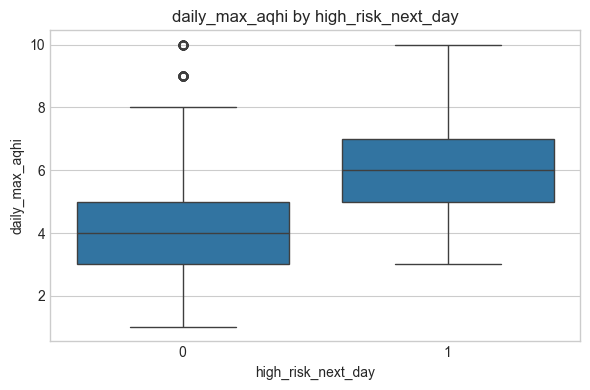

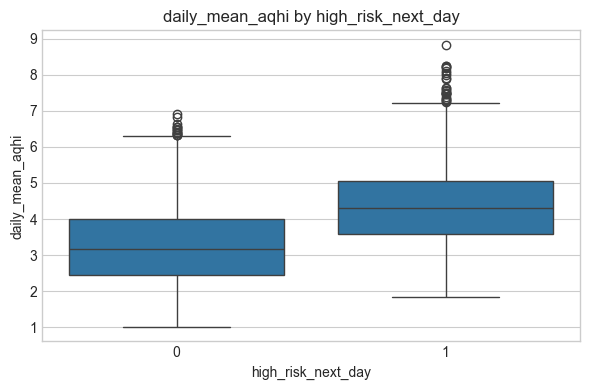

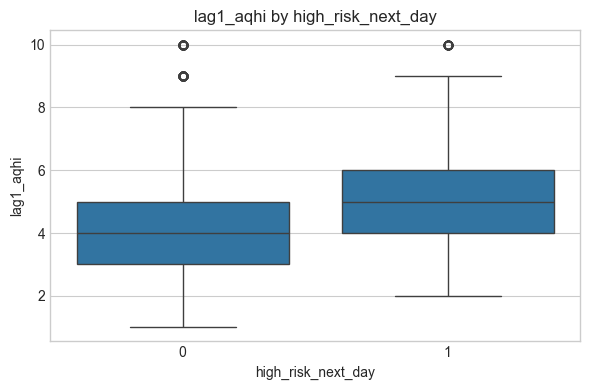

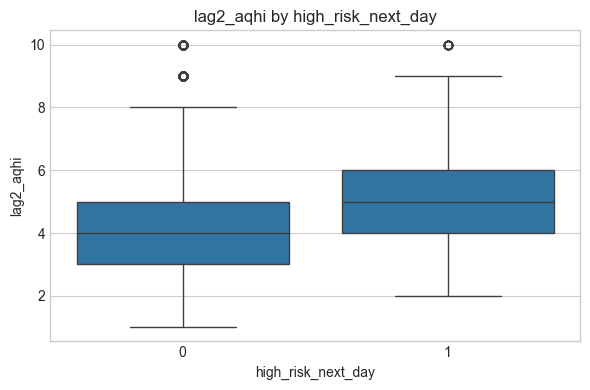

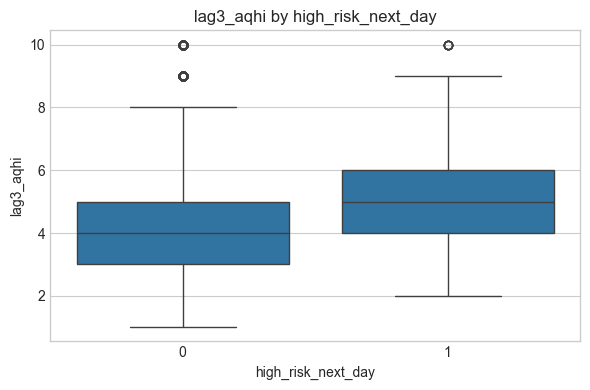

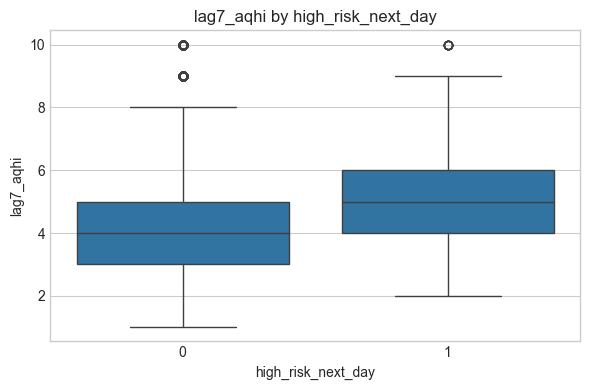

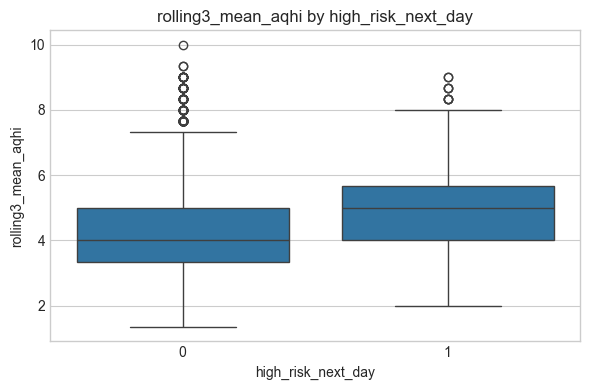

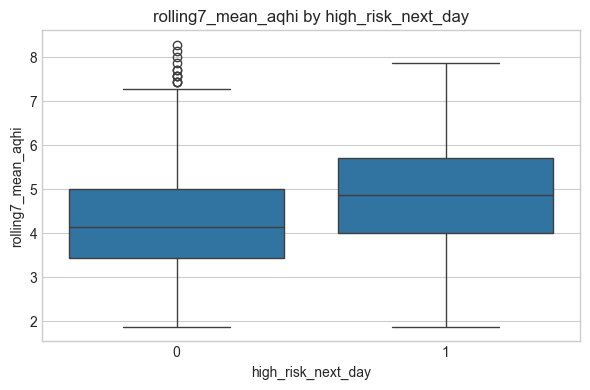

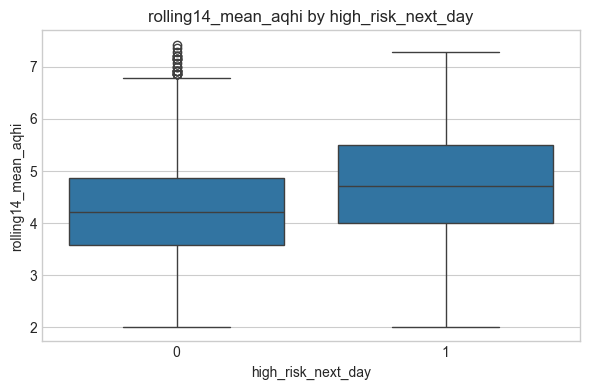

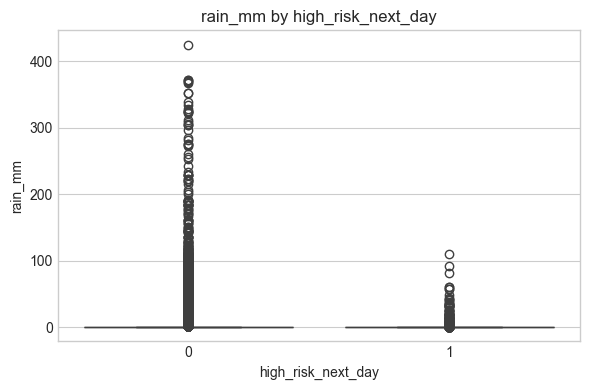

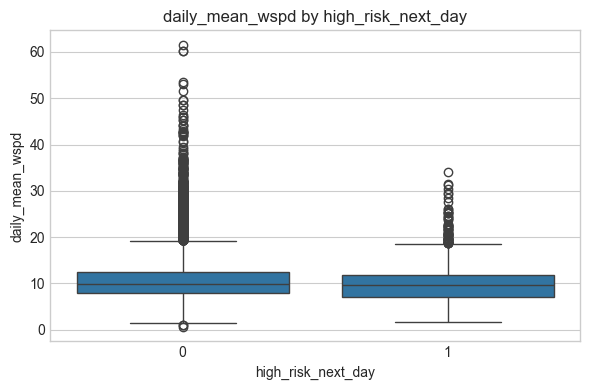

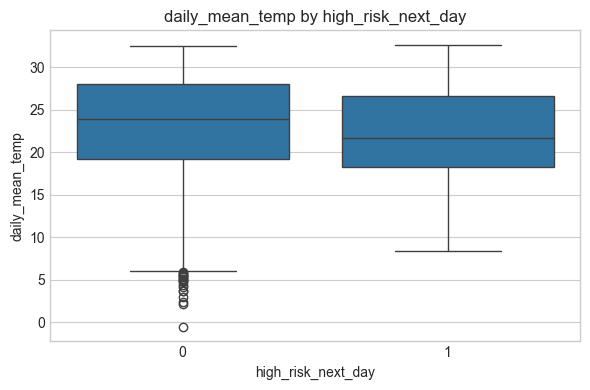

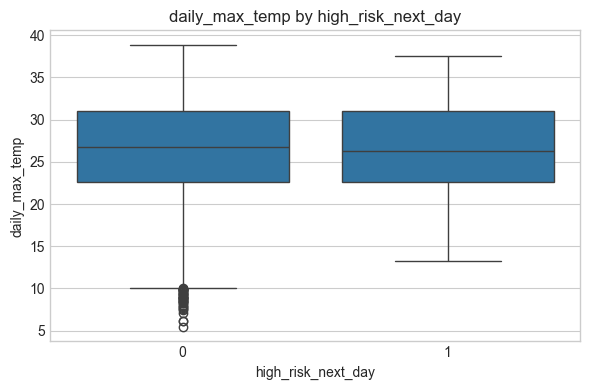

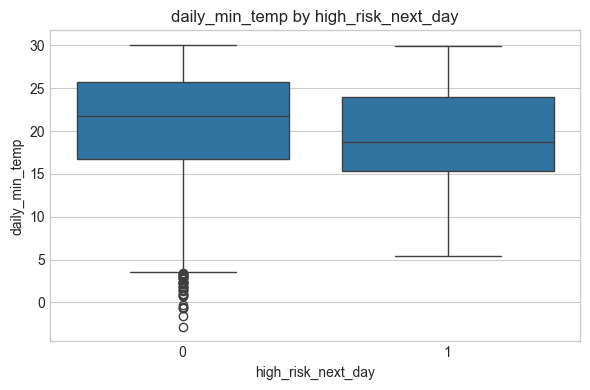

In [ ]:

# 12. Boxplots by target

plot_cols = [
    "daily_max_aqhi", "daily_mean_aqhi",
    "lag1_aqhi", "lag2_aqhi", "lag3_aqhi", "lag7_aqhi",
    "rolling3_mean_aqhi", "rolling7_mean_aqhi", "rolling14_mean_aqhi",
    "rain_mm", "daily_mean_wspd",
    "daily_mean_temp", "daily_max_temp", "daily_min_temp"
]
plot_cols = [col for col in plot_cols if col in df.columns]

for col in plot_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=target_col, y=col)
    plt.title(f"{col} by {target_col}")
    plt.tight_layout()
    plt.show()

In [ ]:


# 13. Define final feature sets


# Final numeric predictors for Route 2 station-day next-day AQHI forecasting
feature_numeric = [
    "daily_max_aqhi",
    "daily_mean_aqhi",
    "lag1_aqhi",
    "lag2_aqhi",
    "lag3_aqhi",
    "lag7_aqhi",
    "rolling3_mean_aqhi",
    "rolling7_mean_aqhi",
    "rolling14_mean_aqhi",
    "rain_mm",
    "rain_trace_flag",
    "rain_occurrence_flag",
    "daily_mean_wspd",
    "daily_mean_temp",
    "daily_max_temp",
    "daily_min_temp",
    "month",
    "day_of_week",
    "is_weekend",
    "rain_missing_flag",
    "wind_missing_flag",
    "temp_missing_flag"
]

feature_numeric = [col for col in feature_numeric if col in df.columns]

# Keep both District and station:
# - District = spatial unit used for weather matching
# - station  = AQHI monitoring location identifier
feature_categorical = ["District", "station"]
feature_categorical = [col for col in feature_categorical if col in df.columns]

print("Final numeric features:")
print(feature_numeric)

print("\nFinal categorical features:")
print(feature_categorical)

Final numeric features:
['daily_max_aqhi', 'daily_mean_aqhi', 'lag1_aqhi', 'lag2_aqhi', 'lag3_aqhi', 'lag7_aqhi', 'rolling3_mean_aqhi', 'rolling7_mean_aqhi', 'rolling14_mean_aqhi', 'rain_mm', 'rain_trace_flag', 'rain_occurrence_flag', 'daily_mean_wspd', 'daily_mean_temp', 'daily_max_temp', 'daily_min_temp', 'month', 'day_of_week', 'is_weekend', 'rain_missing_flag', 'wind_missing_flag', 'temp_missing_flag']

Final categorical features:
['District', 'station']


In [ ]:

# 14. Create model dataframe


keep_cols = ["date", target_col] + feature_numeric + feature_categorical
model_df = df[keep_cols].copy()

print("\nModel dataframe shape (before cleaning):", model_df.shape)
print(model_df.head())

# Drop rows with missing target
model_df = model_df.dropna(subset=[target_col]).copy()

print("\nAfter dropping missing target:", model_df.shape)


Model dataframe shape (before cleaning): (21329, 26)
        date  high_risk_next_day  daily_max_aqhi  daily_mean_aqhi  lag1_aqhi  lag2_aqhi  lag3_aqhi  lag7_aqhi  rolling3_mean_aqhi  rolling7_mean_aqhi  rolling14_mean_aqhi  rain_mm  rain_trace_flag  \
0 2023-01-01                   0             4.0         3.541667        NaN        NaN        NaN        NaN                 NaN                 NaN                  NaN      0.0                0   
1 2023-01-02                   0             5.0         3.625000        4.0        NaN        NaN        NaN                 NaN                 NaN                  NaN      0.0                0   
2 2023-01-03                   0             5.0         3.416667        5.0        4.0        NaN        NaN                 NaN                 NaN                  NaN      0.0                0   
3 2023-01-04                   1             5.0         3.791667        5.0        5.0        4.0        NaN            4.666667                 

In [ ]:

# 14B. Drop rows with missing lag / rolling AQHI features


# These missing values are structural:
# early dates in each station series do not yet have enough history for lag/rolling features.
lag_roll_cols = [
    "lag1_aqhi",
    "lag2_aqhi",
    "lag3_aqhi",
    "lag7_aqhi",
    "rolling3_mean_aqhi",
    "rolling7_mean_aqhi",
    "rolling14_mean_aqhi"
]

lag_roll_cols = [col for col in lag_roll_cols if col in model_df.columns]

print("\nBefore dropping lag/rolling missing rows:", model_df.shape)
print(model_df[lag_roll_cols].isna().sum())

model_df = model_df.dropna(subset=lag_roll_cols).copy()

print("\nAfter dropping lag/rolling missing rows:", model_df.shape)


Before dropping lag/rolling missing rows: (21329, 26)
lag1_aqhi               19
lag2_aqhi               37
lag3_aqhi               55
lag7_aqhi              127
rolling3_mean_aqhi      57
rolling7_mean_aqhi     133
rolling14_mean_aqhi    266
dtype: int64

After dropping lag/rolling missing rows: (21063, 26)


In [ ]:

# 15. Chronological split by date


# Fixed split date for reproducibility
split_date = pd.Timestamp("2025-09-05")

# If you prefer automatic 80/20 date split instead, use:
# unique_dates = np.sort(model_df["date"].dropna().unique())
# split_idx = int(len(unique_dates) * 0.8)
# split_date = unique_dates[split_idx]

print("Split date:", split_date)

train_df = model_df[model_df["date"] < split_date].copy()
test_df  = model_df[model_df["date"] >= split_date].copy()

print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())

print("\nTrain target rate:", train_df[target_col].mean())
print("Test target rate:", test_df[target_col].mean())

Split date: 2025-09-05 00:00:00

Train shape: (16797, 26)
Test shape: (4266, 26)

Train date range: 2023-01-15 00:00:00 to 2025-09-04 00:00:00
Test date range: 2025-09-05 00:00:00 to 2026-04-29 00:00:00

Train target rate: 0.07239387985949872
Test target rate: 0.052742616033755275


In [ ]:

# 16. One-hot encoding


train_encoded = pd.get_dummies(train_df, columns=feature_categorical, drop_first=True)
test_encoded  = pd.get_dummies(test_df, columns=feature_categorical, drop_first=True)

# Align columns between train and test
train_encoded, test_encoded = train_encoded.align(
    test_encoded, join="outer", axis=1, fill_value=0
)

print("Encoded train shape:", train_encoded.shape)
print("Encoded test shape:", test_encoded.shape)

Encoded train shape: (16797, 56)
Encoded test shape: (4266, 56)


In [ ]:

# 17. Split X and y


drop_cols = ["date", target_col]

X_train = train_encoded.drop(columns=drop_cols)
y_train = train_encoded[target_col]

X_test = test_encoded.drop(columns=drop_cols)
y_test = test_encoded[target_col]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nX_train columns:")
print(X_train.columns.tolist())

X_train shape: (16797, 54)
y_train shape: (16797,)
X_test shape: (4266, 54)
y_test shape: (4266,)

X_train columns:
['daily_max_aqhi', 'daily_mean_aqhi', 'lag1_aqhi', 'lag2_aqhi', 'lag3_aqhi', 'lag7_aqhi', 'rolling3_mean_aqhi', 'rolling7_mean_aqhi', 'rolling14_mean_aqhi', 'rain_mm', 'rain_trace_flag', 'rain_occurrence_flag', 'daily_mean_wspd', 'daily_mean_temp', 'daily_max_temp', 'daily_min_temp', 'month', 'day_of_week', 'is_weekend', 'rain_missing_flag', 'wind_missing_flag', 'temp_missing_flag', 'District_Eastern', 'District_Islands', 'District_Kwai Tsing', 'District_Kwun Tong', 'District_North', 'District_Sai Kung', 'District_Sha Tin', 'District_Sham Shui Po', 'District_Southern', 'District_Tai Po', 'District_Tsuen Wan', 'District_Tuen Mun', 'District_Wan Chai', 'District_Yau Tsim Mong', 'District_Yuen Long', 'station_Central', 'station_Central/Western', 'station_Eastern', 'station_Kwai Chung', 'station_Kwun Tong', 'station_Mong Kok', 'station_North', 'station_Sha Tin', 'station_Sham

In [ ]:

# 18. Save outputs

model_df.to_csv("model_dataset_full.csv", index=False)
train_df.to_csv("train_dataset_raw.csv", index=False)
test_df.to_csv("test_dataset_raw.csv", index=False)

train_encoded.to_csv("train_dataset_encoded.csv", index=False)
test_encoded.to_csv("test_dataset_encoded.csv", index=False)

X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("\nSaved:")
print("- model_dataset_full.csv")
print("- train_dataset_raw.csv")
print("- test_dataset_raw.csv")
print("- train_dataset_encoded.csv")
print("- test_dataset_encoded.csv")
print("- X_train.csv")
print("- X_test.csv")
print("- y_train.csv")
print("- y_test.csv")


Saved:
- model_dataset_full.csv
- train_dataset_raw.csv
- test_dataset_raw.csv
- train_dataset_encoded.csv
- test_dataset_encoded.csv
- X_train.csv
- X_test.csv
- y_train.csv
- y_test.csv


In [ ]:

# 19. Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:

# 20. Impute missing values

imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Remaining missing values in X_train_imputed:", X_train_imputed.isna().sum().sum())
print("Remaining missing values in X_test_imputed:", X_test_imputed.isna().sum().sum())

Remaining missing values in X_train_imputed: 0
Remaining missing values in X_test_imputed: 0


In [ ]:

# 21. Define evaluation function

def evaluate_model(model, X_train, y_train, X_test, y_test, threshold=0.5, model_name="Model"):
    """
    Fit model, predict probabilities, apply threshold, and return metrics.
    """
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
        y_prob = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-8)

    y_pred = (y_prob >= threshold).astype(int)

    results = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

    cm = confusion_matrix(y_test, y_pred)

    return results, cm, y_pred, y_prob

In [ ]:

# 22. Define models

logit_model = LogisticRegression(max_iter=2000, random_state=42)

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

logit_bal = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

tree_bal = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

rf_bal = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [ ]:

# 23. Evaluate all models

model_dict = {
    "Logistic Regression": logit_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "Logistic Regression (balanced)": logit_bal,
    "Decision Tree (balanced)": tree_bal,
    "Random Forest (balanced)": rf_bal
}

all_results = []
model_outputs = {}

for name, model in model_dict.items():
    results, cm, y_pred, y_prob = evaluate_model(
        model,
        X_train_imputed, y_train,
        X_test_imputed, y_test,
        threshold=0.5,
        model_name=name
    )
    all_results.append(results)
    model_outputs[name] = {
        "model": model,
        "cm": cm,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

results_df = pd.DataFrame(all_results)

metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
results_df[metric_cols] = results_df[metric_cols].round(4)

print("Model comparison results:")
print(results_df.sort_values(by=["Recall", "F1", "ROC_AUC"], ascending=False))

Model comparison results:
                            Model  Threshold  Accuracy  Precision  Recall      F1  ROC_AUC
3  Logistic Regression (balanced)        0.5    0.7433     0.1237  0.6356  0.2071   0.6974
4        Decision Tree (balanced)        0.5    0.6463     0.0831  0.5689  0.1450   0.7022
5        Random Forest (balanced)        0.5    0.7536     0.1074  0.5022  0.1770   0.6884
0             Logistic Regression        0.5    0.9437     0.2727  0.0400  0.0698   0.7131
1                   Decision Tree        0.5    0.9466     0.2857  0.0089  0.0172   0.7051
2                   Random Forest        0.5    0.9475     1.0000  0.0044  0.0088   0.7103


In [ ]:

# 24. Detailed classification reports

for name in model_dict.keys():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Confusion Matrix:")
    print(pd.DataFrame(
        model_outputs[name]["cm"],
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))

    print("\nClassification Report:")
    print(classification_report(y_test, model_outputs[name]["y_pred"], zero_division=0))


Logistic Regression
Confusion Matrix:
          Pred 0  Pred 1
Actual 0    4017      24
Actual 1     216       9

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      4041
           1       0.27      0.04      0.07       225

    accuracy                           0.94      4266
   macro avg       0.61      0.52      0.52      4266
weighted avg       0.91      0.94      0.92      4266


Decision Tree
Confusion Matrix:
          Pred 0  Pred 1
Actual 0    4036       5
Actual 1     223       2

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      4041
           1       0.29      0.01      0.02       225

    accuracy                           0.95      4266
   macro avg       0.62      0.50      0.49      4266
weighted avg       0.91      0.95      0.92      4266


Random Forest
Confusion Matrix:
          Pred 0  Pred 1
Actual 0    4041  

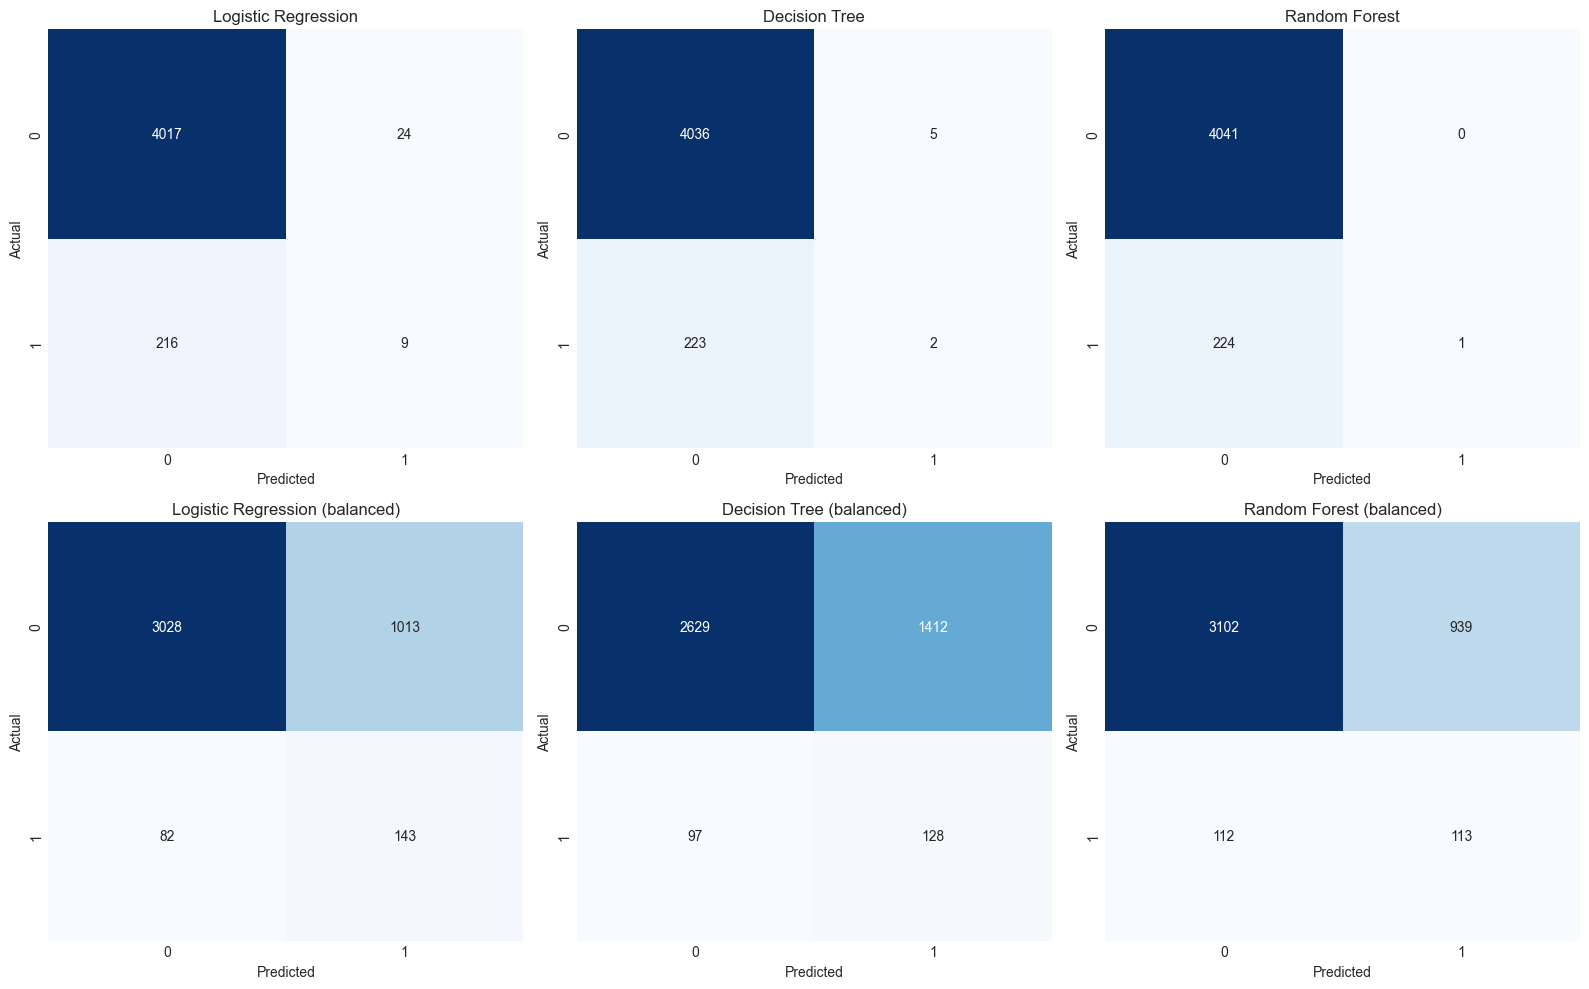

In [ ]:

# 25. Confusion matrix plots

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, name in zip(axes, model_dict.keys()):
    cm = model_outputs[name]["cm"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:

# 26. Sorted comparison table

comparison_df = results_df.sort_values(
    by=["Recall", "F1", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

print("\nSorted model comparison:")
print(comparison_df)


Sorted model comparison:
                            Model  Threshold  Accuracy  Precision  Recall      F1  ROC_AUC
0  Logistic Regression (balanced)        0.5    0.7433     0.1237  0.6356  0.2071   0.6974
1        Decision Tree (balanced)        0.5    0.6463     0.0831  0.5689  0.1450   0.7022
2        Random Forest (balanced)        0.5    0.7536     0.1074  0.5022  0.1770   0.6884
3             Logistic Regression        0.5    0.9437     0.2727  0.0400  0.0698   0.7131
4                   Decision Tree        0.5    0.9466     0.2857  0.0089  0.0172   0.7051
5                   Random Forest        0.5    0.9475     1.0000  0.0044  0.0088   0.7103


In [ ]:

# 27. Select best model candidate

best_row = comparison_df.iloc[0]
best_model_name = best_row["Model"]

print("Best model candidate based on Recall, then F1, then ROC-AUC:")
print(best_row)

best_model = model_outputs[best_model_name]["model"]
best_probs = model_outputs[best_model_name]["y_prob"]
best_preds = model_outputs[best_model_name]["y_pred"]
best_cm = model_outputs[best_model_name]["cm"]

Best model candidate based on Recall, then F1, then ROC-AUC:
Model        Logistic Regression (balanced)
Threshold                               0.5
Accuracy                             0.7433
Precision                            0.1237
Recall                               0.6356
F1                                   0.2071
ROC_AUC                              0.6974
Name: 0, dtype: object


In [ ]:

# 28. Threshold tuning on Random Forest (balanced)

threshold_candidates = [0.5, 0.4, 0.3, 0.2]

threshold_results = []
rf_bal_model = model_dict["Random Forest (balanced)"]

for th in threshold_candidates:
    result, cm, pred, prob = evaluate_model(
        rf_bal_model,
        X_train_imputed, y_train,
        X_test_imputed, y_test,
        threshold=th,
        model_name="Random Forest (balanced)"
    )
    threshold_results.append(result)

threshold_df = pd.DataFrame(threshold_results)
threshold_df[metric_cols] = threshold_df[metric_cols].round(4)

print("Threshold tuning results:")
print(threshold_df)

Threshold tuning results:
                      Model  Threshold  Accuracy  Precision  Recall      F1  ROC_AUC
0  Random Forest (balanced)        0.5    0.7536     0.1074  0.5022  0.1770   0.6884
1  Random Forest (balanced)        0.4    0.6540     0.0946  0.6489  0.1652   0.6884
2  Random Forest (balanced)        0.3    0.5422     0.0785  0.7156  0.1415   0.6884
3  Random Forest (balanced)        0.2    0.3575     0.0650  0.8356  0.1206   0.6884


In [ ]:

# 28B. Threshold tuning on Logistic Regression (balanced)

threshold_candidates = [0.5, 0.4, 0.3, 0.2]

logit_threshold_results = []
logit_threshold_outputs = {}

logit_bal_model = model_dict["Logistic Regression (balanced)"]

for th in threshold_candidates:
    result, cm, pred, prob = evaluate_model(
        logit_bal_model,
        X_train_imputed, y_train,
        X_test_imputed, y_test,
        threshold=th,
        model_name="Logistic Regression (balanced)"
    )
    logit_threshold_results.append(result)
    logit_threshold_outputs[th] = {
        "cm": cm,
        "pred": pred,
        "prob": prob
    }

logit_threshold_df = pd.DataFrame(logit_threshold_results)
logit_threshold_df[metric_cols] = logit_threshold_df[metric_cols].round(4)

print("Threshold tuning results - Logistic Regression (balanced):")
print(logit_threshold_df)

Threshold tuning results - Logistic Regression (balanced):
                            Model  Threshold  Accuracy  Precision  Recall      F1  ROC_AUC
0  Logistic Regression (balanced)        0.5    0.7433     0.1237  0.6356  0.2071   0.6974
1  Logistic Regression (balanced)        0.4    0.6554     0.1012  0.7022  0.1769   0.6974
2  Logistic Regression (balanced)        0.3    0.5406     0.0807  0.7422  0.1456   0.6974
3  Logistic Regression (balanced)        0.2    0.4004     0.0672  0.8044  0.1240   0.6974


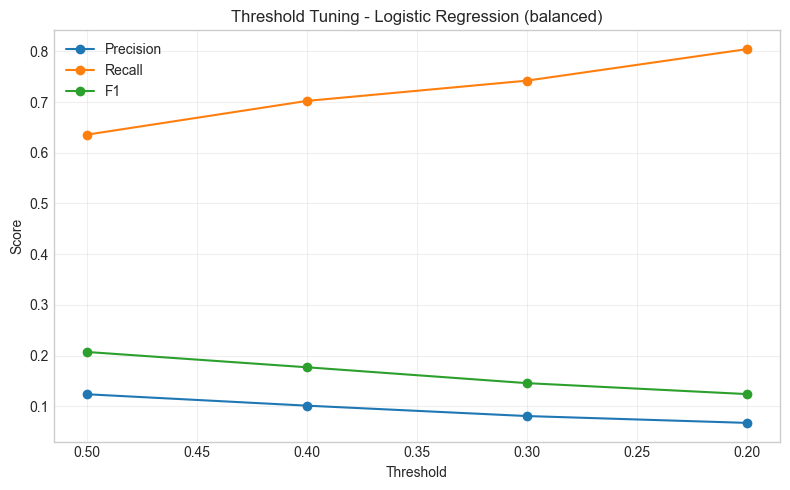

In [ ]:

# 28C. Threshold tuning plot - Logistic Regression (balanced)

plt.figure(figsize=(8, 5))
plt.plot(logit_threshold_df["Threshold"], logit_threshold_df["Precision"], marker="o", label="Precision")
plt.plot(logit_threshold_df["Threshold"], logit_threshold_df["Recall"], marker="o", label="Recall")
plt.plot(logit_threshold_df["Threshold"], logit_threshold_df["F1"], marker="o", label="F1")

plt.gca().invert_xaxis()
plt.title("Threshold Tuning - Logistic Regression (balanced)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

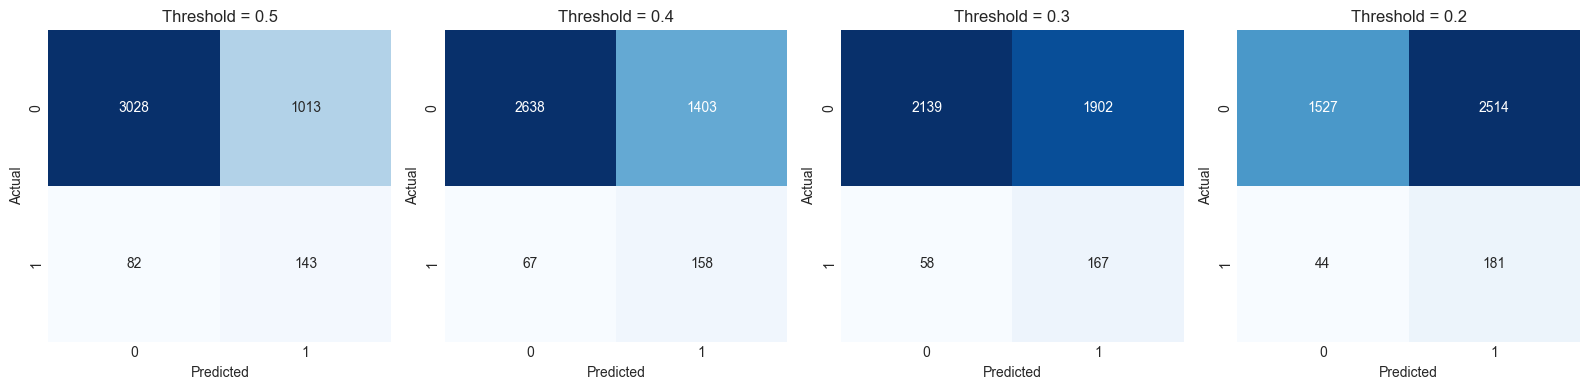

In [ ]:

# 28D. Confusion matrices across thresholds - Logistic Regression (balanced)

fig, axes = plt.subplots(1, len(threshold_candidates), figsize=(4 * len(threshold_candidates), 4))

for ax, th in zip(axes, threshold_candidates):
    cm = logit_threshold_outputs[th]["cm"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"Threshold = {th}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [219]:
# Add FP / FN counts
logit_threshold_df["TN"] = [logit_threshold_outputs[th]["cm"][0, 0] for th in threshold_candidates]
logit_threshold_df["FP"] = [logit_threshold_outputs[th]["cm"][0, 1] for th in threshold_candidates]
logit_threshold_df["FN"] = [logit_threshold_outputs[th]["cm"][1, 0] for th in threshold_candidates]
logit_threshold_df["TP"] = [logit_threshold_outputs[th]["cm"][1, 1] for th in threshold_candidates]

print(logit_threshold_df[["Threshold", "Precision", "Recall", "F1", "FP", "FN", "TP"]])

   Threshold  Precision  Recall      F1    FP  FN   TP
0        0.5     0.1237  0.6356  0.2071  1013  82  143
1        0.4     0.1012  0.7022  0.1769  1403  67  158
2        0.3     0.0807  0.7422  0.1456  1902  58  167
3        0.2     0.0672  0.8044  0.1240  2514  44  181


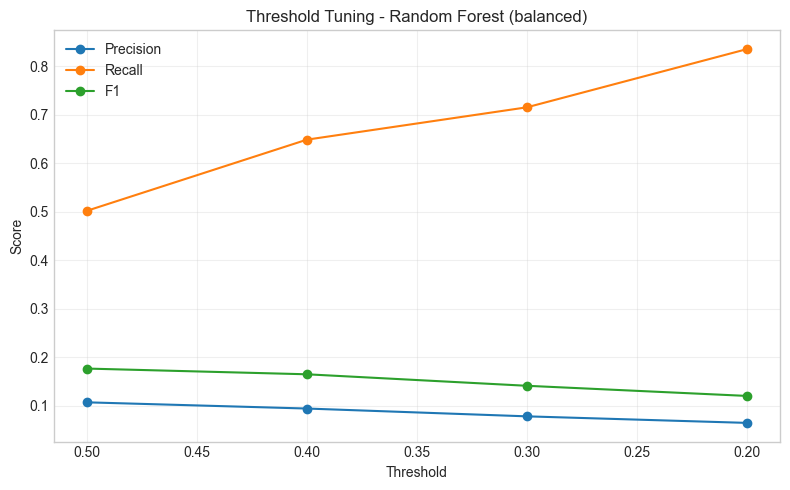

In [ ]:

# 29. Threshold tuning plot

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")

plt.gca().invert_xaxis()
plt.title("Threshold Tuning - Random Forest (balanced)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

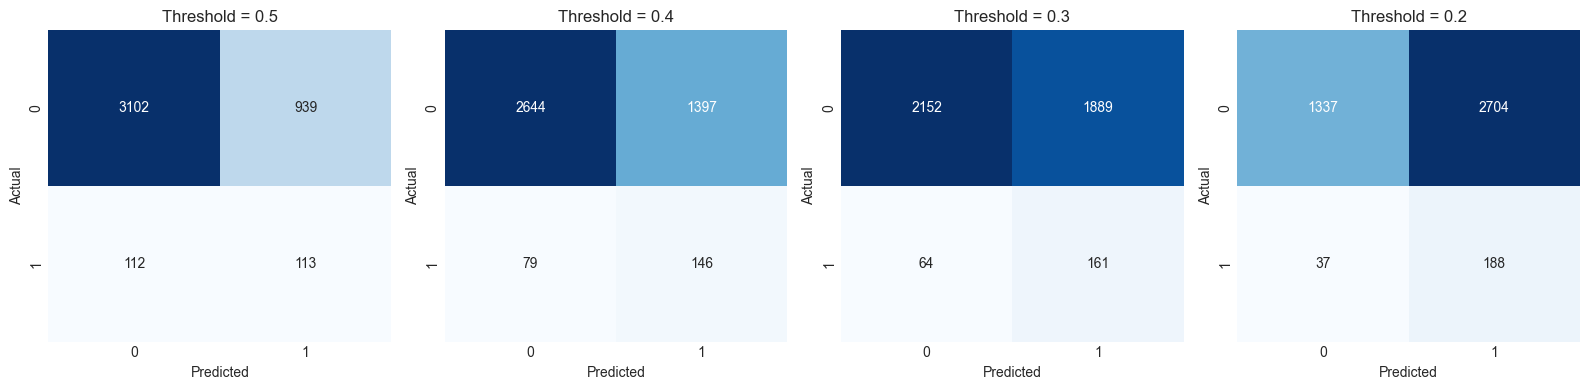

In [ ]:

# 30. Confusion matrices across thresholds

fig, axes = plt.subplots(1, len(threshold_candidates), figsize=(4 * len(threshold_candidates), 4))

for ax, th in zip(axes, threshold_candidates):
    _, cm, pred, prob = evaluate_model(
        rf_bal_model,
        X_train_imputed, y_train,
        X_test_imputed, y_test,
        threshold=th,
        model_name=f"RF balanced @ {th}"
    )
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"Threshold = {th}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:

# 31. Feature importance - Random Forest (balanced)

rf_bal.fit(X_train_imputed, y_train)

feature_importance = pd.Series(
    rf_bal.feature_importances_,
    index=X_train_imputed.columns
).sort_values(ascending=False)

top_n = 20
top_features = feature_importance.head(top_n)

print(f"Top {top_n} feature importances:")
print(top_features)

Top 20 feature importances:
daily_max_aqhi          0.221151
daily_mean_aqhi         0.153460
daily_max_temp          0.071568
lag1_aqhi               0.066103
rolling7_mean_aqhi      0.053538
daily_min_temp          0.048465
daily_mean_temp         0.047378
rolling3_mean_aqhi      0.047335
rolling14_mean_aqhi     0.039063
month                   0.031783
rain_mm                 0.031776
daily_mean_wspd         0.031675
lag2_aqhi               0.026930
lag7_aqhi               0.023468
day_of_week             0.021165
lag3_aqhi               0.019384
rain_occurrence_flag    0.014982
is_weekend              0.007363
District_Tuen Mun       0.003873
District_Islands        0.003294
dtype: float64


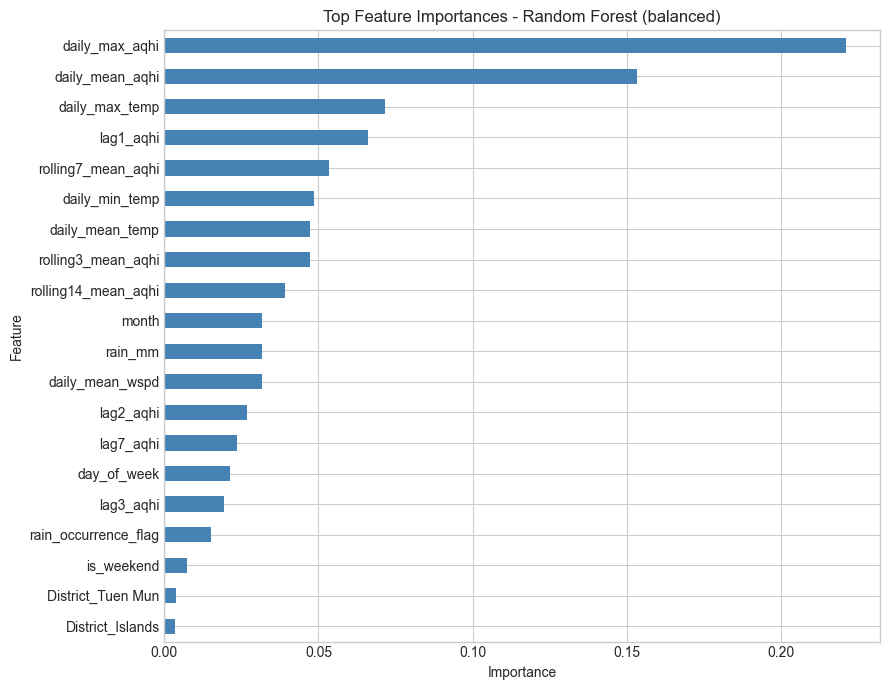

In [ ]:

# 32. Plot feature importance

plt.figure(figsize=(9, 7))
top_features.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top Feature Importances - Random Forest (balanced)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:

# 33. Logistic regression coefficients (balanced)

logit_bal.fit(X_train_imputed, y_train)

coef_df = pd.DataFrame({
    "Feature": X_train_imputed.columns,
    "Coefficient": logit_bal.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("Top positive coefficients:")
print(coef_df.head(15))

print("\nTop negative coefficients:")
print(coef_df.tail(15))

Top positive coefficients:
               Feature  Coefficient
7   rolling7_mean_aqhi     0.564300
10     rain_trace_flag     0.533485
0       daily_max_aqhi     0.488324
1      daily_mean_aqhi     0.480369
50   station_Tsuen Wan     0.422620
32  District_Tsuen Wan     0.422620
18          is_weekend     0.398845
51    station_Tuen Mun     0.290555
33   District_Tuen Mun     0.290555
52  station_Tung Chung     0.259770
23    District_Islands     0.259770
14      daily_max_temp     0.244463
34   District_Wan Chai     0.092386
25  District_Kwun Tong     0.058320
41   station_Kwun Tong     0.058320

Top negative coefficients:
                   Feature  Coefficient
30       District_Southern    -0.237116
46        station_Southern    -0.237116
31         District_Tai Po    -0.247150
42        station_Mong Kok    -0.266046
35  District_Yau Tsim Mong    -0.266046
24     District_Kwai Tsing    -0.311861
40      station_Kwai Chung    -0.311861
37         station_Central    -0.328461
11    rai

In [ ]:

# 34. Error analysis dataframe

error_df = test_df.copy().reset_index(drop=True)

rf_bal_results_05, rf_bal_cm_05, rf_bal_pred_05, rf_bal_prob_05 = evaluate_model(
    rf_bal_model,
    X_train_imputed, y_train,
    X_test_imputed, y_test,
    threshold=0.5,
    model_name="Random Forest (balanced)"
)

error_df["pred"] = rf_bal_pred_05
error_df["prob"] = rf_bal_prob_05
error_df["error_type"] = "correct"

error_df.loc[(error_df[target_col] == 1) & (error_df["pred"] == 0), "error_type"] = "false_negative"
error_df.loc[(error_df[target_col] == 0) & (error_df["pred"] == 1), "error_type"] = "false_positive"

print(error_df["error_type"].value_counts())

error_type
correct           3215
false_positive     939
false_negative     112
Name: count, dtype: int64


In [ ]:

# 35. Error summaries

print("\nErrors by month:")
print(error_df.groupby(["month", "error_type"]).size().unstack(fill_value=0))

if "station" in error_df.columns:
    print("\nErrors by station:")
    print(
        error_df.groupby(["station", "error_type"])
        .size()
        .unstack(fill_value=0)
        .sort_values(by="false_negative", ascending=False)
    )

if "District" in error_df.columns:
    print("\nErrors by district:")
    print(
        error_df.groupby(["District", "error_type"])
        .size()
        .unstack(fill_value=0)
        .sort_values(by="false_negative", ascending=False)
    )


Errors by month:
error_type  correct  false_negative  false_positive
month                                              
1               314              33             211
2               416               5              83
3               443               9             106
4               473              22              27
9               442               7              19
10              520               3              35
11              352              17             171
12              255              16             287

Errors by station:
error_type       correct  false_negative  false_positive
station                                                 
Tuen Mun             150              17              70
Yuen Long            181              10              46
Tsuen Wan            215               9              13
Tung Chung           213               9              15
Sha Tin              175               8              54
Central/Western      179               6   

In [ ]:

# 36. Save outputs

results_df.to_csv("model_comparison_results.csv", index=False)
comparison_df.to_csv("model_comparison_sorted.csv", index=False)
threshold_df.to_csv("threshold_tuning_results_rf_balanced.csv", index=False)
feature_importance.to_csv("rf_balanced_feature_importance.csv")
error_df.to_csv("rf_balanced_error_analysis.csv", index=False)

print("Saved files:")
print("- model_comparison_results.csv")
print("- model_comparison_sorted.csv")
print("- threshold_tuning_results_rf_balanced.csv")
print("- rf_balanced_feature_importance.csv")
print("- rf_balanced_error_analysis.csv")

Saved files:
- model_comparison_results.csv
- model_comparison_sorted.csv
- threshold_tuning_results_rf_balanced.csv
- rf_balanced_feature_importance.csv
- rf_balanced_error_analysis.csv
